# 02 · Exploring the data, and preparing it for modelling

**LAEI 2019 · Module End Project**

This notebook is the evidence behind **Task 1** (which machine learning
algorithms I chose, and why) and **Task 2** (what I expect those models to
show). It also produces the prepared tables that notebooks 03–06 use.

It is written to be readable by someone new to machine learning. Every analysis
is followed by a plain-language **"what this means"** box explaining why the
result matters and what it changed about my approach.

### What this project is trying to do

The Department of Environment wants to know: **can machine learning predict
atmospheric emissions from data that boroughs already collect?**

Before choosing any algorithm, the data has to be understood. The point of this
notebook is not to produce charts — it is to answer three questions that
determine everything downstream:

1. **What shape is the data in?** (How is it distributed, what is missing, what
   is trustworthy?)
2. **What structure does it have?** (Which relationships are linear, which are
   not?)
3. **What should therefore be built?**

### How this notebook maps to the report

| Section here | Feeds |
|---|---|
| Part 3 · Finding 1 — uneven spread | Task 1 · why tree models |
| Part 3 · Finding 2 — concentration | Task 2 · Insight 4 |
| Part 3 · Finding 3 — different sources | Task 2 · Insight 5 |
| Part 3 · Finding 4 — a product, not a sum | Task 1 & Task 2 · Insight 7 |
| Part 3 · Finding 5 — quantity vs intensity | Task 2 · Insight 3 |
| Part 4 · data quality | Task 2 · Insight 8 |
| Part 5 · preparation | Task 3 (the modeller's starting point) |

> **Before running this:** run `01_data_acquisition.ipynb` once. It downloads
> the inventory and converts it to CSV. This notebook reads only those CSVs.

In [1]:
import sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

sys.path.append("../src")
import laei

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 60)

ROOT    = Path("..").resolve()
FIGURES = ROOT / "reports" / "figures"
PROC    = ROOT / "data" / "processed"
FIGURES.mkdir(parents=True, exist_ok=True)

INK, ACCENT, OCHRE, BRICK, MUTED = "#121820", "#12484f", "#8f5f14", "#8f3428", "#8894a0"
SEQ = ["#12484f", "#2f7a78", "#5aa89f", "#8f5f14", "#b98a3c", "#8f3428", "#8894a0"]
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 9, "axes.titlesize": 10.5, "axes.titleweight": "semibold",
    "axes.labelsize": 9, "axes.edgecolor": "#c3cbd1", "axes.linewidth": .8,
    "axes.grid": True, "grid.color": "#e3e7ea", "grid.linewidth": .7,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "axes.labelcolor": INK, "axes.titlecolor": INK, "figure.facecolor": "white",
})

def save(fig, name):
    fig.savefig(FIGURES / f"{name}.png")
    print(f"saved -> reports/figures/{name}.png")

RS = laei.RANDOM_STATE
print("pandas", pd.__version__, "| numpy", np.__version__)
import sklearn; print("scikit-learn", sklearn.__version__, "| random_state =", RS)

pandas 3.0.5 | numpy 2.5.2


scikit-learn 1.9.0 | random_state = 42


---
# Part 1 · Where the data comes from

### What is an emissions inventory?

The **London Atmospheric Emissions Inventory (LAEI)** is the Greater London
Authority's estimate of how much air pollution is released across London in a
year. This project uses four pollutants:

| Pollutant | What it is | Main source |
|---|---|---|
| **NOx** | Nitrogen oxides | Combustion — mostly vehicle engines |
| **PM10** | Particles under 10 micrometres | Exhaust, plus brake and tyre wear |
| **PM2.5** | Particles under 2.5 micrometres (a subset of PM10) | As above; more harmful, goes deeper into the lungs |
| **CO2** | Carbon dioxide | All fuel burning |

Everything is measured in **tonnes per year**.

### The most important caveat, stated up front

**LAEI is a *model*, not a set of measurements.**

Nobody stood at 79,000 roadsides with an instrument. The GLA *calculated* these
figures, roughly as:

```
emissions = traffic volume  ×  distance travelled  ×  emission factor
```

where the emission factor is a laboratory constant like *"an average diesel car
emits X grams of NOx per kilometre."*

This matters enormously, and I return to it in Part 3, Finding 4. If a model
scores very highly, the question to ask is whether it predicted *pollution* or
merely reproduced *the GLA's arithmetic*.

In [2]:
# What files are available to work with?
raw     = sorted((ROOT / "data" / "raw").glob("*"))
interim = sorted((ROOT / "data" / "interim").glob("*.xlsx"))
proc    = sorted(PROC.glob("*.csv"))

rows = []
for stage, files in [("1. downloaded (.zip)", raw),
                     ("2. unzipped (.xlsx)", interim),
                     ("3. converted (.csv)", proc)]:
    for f in files:
        rows.append({"stage": stage, "file": f.name, "MB": round(f.stat().st_size / 1e6, 1)})

pd.DataFrame(rows)

,stage,file,MB
0,1. downloaded (.zip),LAEI-2019-Emissions-Summary-including-Forecast...,101.0
1,1. downloaded (.zip),laei-2019-major-roads-vkm-flows-speeds.zip,23.5
2,1. downloaded (.zip),LAEI2019-nox-pm-co2-major-roads-link-emissions...,343.1
3,1. downloaded (.zip),LAEI2019-nox-pm-co2-minor-roads-grid-emissions...,16.2
4,1. downloaded (.zip),LAEI2019-nox-pm-cold-start-grid-emissions.zip,3.1
5,1. downloaded (.zip),LAEI2019-Supporting-Information-GIS-Files.zip,2.7
6,2. unzipped (.xlsx),LAEI-2019-Emissions-Summary-including-Forecast...,119.9
7,2. unzipped (.xlsx),laei-2019-major-roads-vkm-flows-speeds.xlsx,23.5
8,2. unzipped (.xlsx),LAEI2019-nox-pm-co2-major-roads-link-emissions...,345.4
9,2. unzipped (.xlsx),LAEI2019-nox-pm-co2-minor-roads-grid-emissions...,16.2


**Source.** London Datastore dataset `e758q`, published by the GLA Environment
Team under the UK Open Government Licence v3.0.

One point of governance worth recording: LAEI 2019 was **superseded by LAEI 2022
in August 2025**. It is still published, and it is the dataset this brief
specifies — but I note the supersession, and I built the pipeline so it can be
re-pointed at the newer release.

---
# Part 2 · Meeting the data

The inventory provides information at **two different scales**. Keeping them
straight matters, because different questions live at each.

| | Grid cells | Road links |
|---|---|---|
| **What is one row?** | A 1 km × 1 km square of London | One segment of road, roughly junction to junction |
| **How many?** | 3,460 | 79,388 |
| **What does it tell you?** | Emissions split across 16 *sectors* (road, heating, aviation, river…) | Traffic counts by vehicle type, speed, length, and emissions |
| **Good for** | *What kind of place is this?* | *What does this road emit?* |

I start with the grid.

In [3]:
# Load the grid table. It contains five years; keep only the 2019 base year.
grid_all = pd.read_csv(PROC / "grid_all_years.csv", low_memory=False)

print(f"the full file has {grid_all.shape[0]:,} rows and {grid_all.shape[1]} columns")
print("\nrows available per year:")
print(grid_all["Year"].value_counts().sort_index().to_string())

the full file has 699,120 rows and 30 columns

rows available per year:


Year
2013    134940
2016    134940
2019    143976
2025    142632
2030    142632


### Why we use only 2019

The file offers five years, but **2025 and 2030 are GLA *forecasts*, not
observations** — they are projections of what emissions might be under assumed
future policy.

Mixing forecasts into a model of 2019 would mean training partly on someone
else's predictions. So we filter to the base year and set the forecast years
aside.

In [4]:
g = laei.load_grid(2019)          # filters to 2019 and tidies the zone labels

print(f"2019 rows                : {len(g):,}")
print(f"unique 1 km cells        : {g['Grid ID 2019'].nunique():,}")
print(f"boroughs (+ 'Non GLA')   : {g['Borough'].nunique()}")
print(f"zones                    : {sorted(g['Zone'].unique())}")
print(f"emission sectors         : {g['Sector'].nunique()}")
print(f"individual sources       : {g['Source'].nunique()}")
print(f"units                    : {g['Emissions Unit'].unique()[0]}")

2019 rows                : 143,976
unique 1 km cells        : 3,460
boroughs (+ 'Non GLA')   : 34
zones                    : ['Central', 'Inner', 'Non GLA', 'Outer']
emission sectors         : 16
individual sources       : 39
units                    : tonnes/annum


So each 1 km square appears **many times** — once for every combination of
sector and source. That is why 3,460 cells produce 143,976 rows. These are
added up per cell shortly.

### Which pollutants can actually be modelled?

The file has 19 pollutant columns. That sounds generous, but most are barely
populated. A blank does **not** mean "zero pollution measured" — it means *"this
pollutant is not estimated for this source."*

Count how much of each is actually there.

In [5]:
coverage = pd.DataFrame({
    "rows_with_a_value": g[laei.POLLUTANTS].notna().sum(),
    "percent_populated": (g[laei.POLLUTANTS].notna().mean() * 100).round(1),
    "total_tonnes_2019": g[laei.POLLUTANTS].sum().round(1),
})
coverage = coverage.sort_values("total_tonnes_2019", ascending=False)

# mark the four I decided to model
coverage["we_model_this"] = ["yes" if p in laei.MODELLABLE else ""
                             for p in coverage.index]
coverage

,rows_with_a_value,percent_populated,total_tonnes_2019,we_model_this
co2,112836,78.4,29064344.0,yes
nox,123216,85.6,45405.4,yes
ch4,51900,36.0,35358.6,
co,51900,36.0,22879.0,
nmvoc,55360,38.5,10486.6,
pm10,140516,97.6,9162.1,yes
pm2.5,140516,97.6,4010.0,yes
nh3,31140,21.6,1334.1,
so2,34600,24.0,1121.9,
n2o,34600,24.0,754.3,


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


saved -> reports/figures/01_pollutant_coverage.png


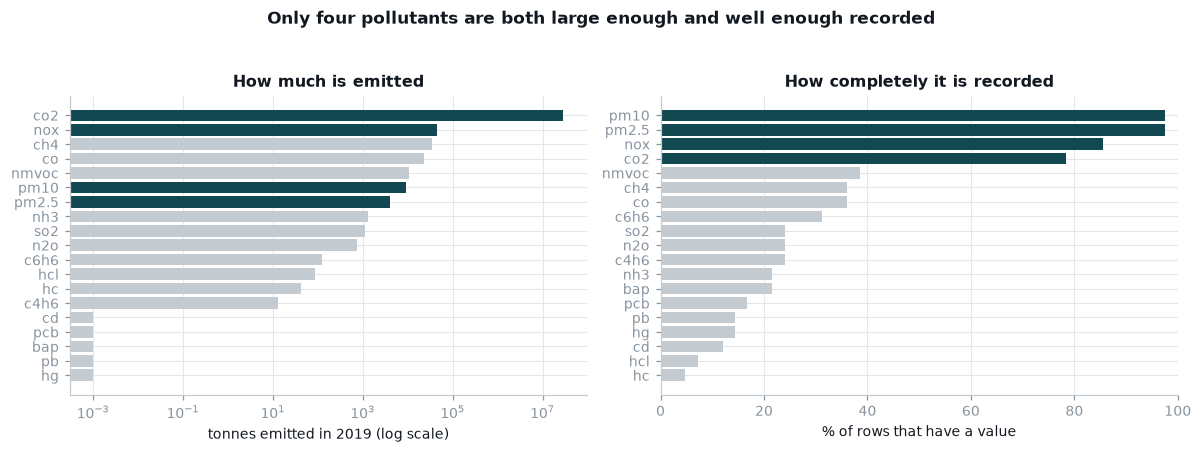

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))

# --- left: how much of each pollutant is emitted (log scale, values span a lot)
left = coverage.sort_values("total_tonnes_2019")
colours = [ACCENT if p in laei.MODELLABLE else "#c3cbd1" for p in left.index]
axes[0].barh(left.index, left["total_tonnes_2019"].clip(lower=1e-3), color=colours)
axes[0].set_xscale("log")
axes[0].set_xlabel("tonnes emitted in 2019 (log scale)")
axes[0].set_title("How much is emitted")

# --- right: how completely each pollutant is recorded
right = coverage.sort_values("percent_populated")
colours = [ACCENT if p in laei.MODELLABLE else "#c3cbd1" for p in right.index]
axes[1].barh(right.index, right["percent_populated"], color=colours)
axes[1].set_xlim(0, 100)
axes[1].set_xlabel("% of rows that have a value")
axes[1].set_title("How completely it is recorded")

fig.suptitle("Only four pollutants are both large enough and well enough recorded",
             y=1.04, fontsize=11, fontweight="semibold", color=INK)
plt.tight_layout(); save(fig, "01_pollutant_coverage"); plt.show()

> ### What this means
>
> **We model NOx, PM10, PM2.5 and CO2 — and nothing else.** The teal bars are
> both substantial in mass and well recorded. The grey ones are either trace
> quantities (heavy metals measured in kilograms across all of London) or
> recorded for too few sources to learn from.
>
> **check coverage before choosing a target.**
> A model trained on a column that is 95% blank will produce confident nonsense.
>
> It also settles how to handle the blanks. When sectors are added up to get a
> cell total, treating a blank as zero is correct — an unestimated source
> contributes nothing to the inventory. But **filling blanks with the column
> average would be indefensible**, because it would invent pollution that the
> GLA never estimated.

---
# Part 3 · Five findings that shaped the project

This is the core of the notebook. Each finding is a property of the data that
changed a decision — and each maps to a claim in the Task 1 / Task 2 report.

## Finding 1 — Emissions are spread extremely unevenly

Right now the data has one row per cell *per sector*. To ask "how polluted is
this square?" everything is first added up per cell.

In [7]:
# one row per 1 km cell, with its total emissions of each pollutant
cell_totals = g.groupby("Grid ID 2019")[laei.MODELLABLE].sum()

print(f"one row per cell now: {cell_totals.shape}\n")
summary = cell_totals.describe().T[["mean", "std", "min", "50%", "max"]]
summary = summary.rename(columns={"50%": "median"})
summary.round(3)

one row per cell now: (3460, 4)



,mean,std,min,median,max
nox,13.123,30.261,0.003,7.485,1012.088
pm10,2.648,4.977,0.009,1.500,120.426
pm2.5,1.159,1.489,0.002,0.784,26.890
co2,8400.099,21387.640,0.007,5330.971,751577.537


Look carefully at the **median** and **max** columns for NOx.

- A typical square emits about **7.5 tonnes** of NOx a year.
- The worst square emits over **1,000 tonnes** — around 135 times more.
- The **mean is well above the median**, which always signals a long tail.

Here is the shape of that distribution.

saved -> reports/figures/02_cell_distributions.png


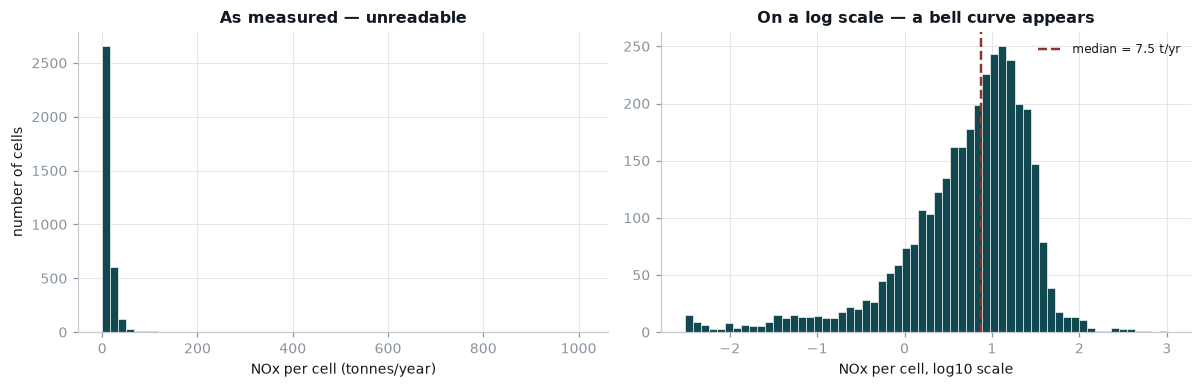

mean      13.12 t/yr
median     7.49 t/yr   <- the typical cell
max     1012.09 t/yr   <- 135x the median


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

nox = cell_totals["nox"]

# --- left: the raw values. Almost everything squashes against zero.
axes[0].hist(nox, bins=60, color=ACCENT, edgecolor="white", linewidth=.4)
axes[0].set_xlabel("NOx per cell (tonnes/year)")
axes[0].set_ylabel("number of cells")
axes[0].set_title("As measured — unreadable")

# --- right: the same data on a log scale, which reveals the real shape
axes[1].hist(np.log10(nox), bins=60, color=ACCENT, edgecolor="white", linewidth=.4)
axes[1].axvline(np.log10(nox.median()), color=BRICK, ls="--", lw=1.6,
                label=f"median = {nox.median():.1f} t/yr")
axes[1].set_xlabel("NOx per cell, log10 scale")
axes[1].set_title("On a log scale — a bell curve appears")
axes[1].legend(frameon=False, fontsize=8)

plt.tight_layout(); save(fig, "02_cell_distributions"); plt.show()

print(f"mean   {nox.mean():8.2f} t/yr")
print(f"median {nox.median():8.2f} t/yr   <- the typical cell")
print(f"max    {nox.max():8.2f} t/yr   <- {nox.max()/nox.median():.0f}x the median")

> ### What this means
>
> The left chart is a classic **right-skewed** (or *log-normal*) distribution:
> most values are small, a few are enormous. The right chart shows that taking
> logarithms turns it into something close to a normal bell curve.
>
> **Three consequences for the modelling:**
>
> 1. **Prefer models that are not thrown off by extreme values.**
>    Linear regression minimises *squared* error, so one 1,000-tonne cell pulls
>    the fitted line far more than a hundred typical cells. Decision trees split
>    on rank order instead — they only care that a value is *bigger*, not by how
>    much. This is one reason We selected Random Forest (Task 1, method 2).
>
> 2. **Never fill missing values with the mean.** On this distribution the mean
>    is not typical of anything. I use the *median* throughout.
>
> 3. **One accuracy number will not be enough.** A score that squares errors
>    (RMSE) will be dominated by a handful of extreme cells, while a score that
>    treats every cell equally (MAE) describes the typical case. They can rank
>    models differently — so I always report both.

## Finding 2 — A small number of places dominate

Finding 1 showed the distribution has a long tail. This asks a sharper
question: **how much of London's pollution sits in how few places?**

The cells are sorted from cleanest to dirtiest and accumulated. This is a **Lorenz
curve**, borrowed from economics, where Lorenz (1905) introduced it to measure the
concentration of wealth; it remains the standard picture of income inequality.

In [9]:
nox_sorted = cell_totals["nox"].sort_values()

# what share of total NOx do the dirtiest X% of cells account for?
for pct in [1, 5, 10, 20, 50]:
    n_cells = int(round(len(nox_sorted) * pct / 100))
    share   = 100 * nox_sorted.tail(n_cells).sum() / nox_sorted.sum()
    print(f"the dirtiest {pct:>2}% of cells ({n_cells:>4,} cells) "
          f"produce {share:5.1f}% of London's NOx")

the dirtiest  1% of cells (  35 cells) produce  16.9% of London's NOx
the dirtiest  5% of cells ( 173 cells) produce  31.9% of London's NOx
the dirtiest 10% of cells ( 346 cells) produce  43.7% of London's NOx
the dirtiest 20% of cells ( 692 cells) produce  61.1% of London's NOx
the dirtiest 50% of cells (1,730 cells) produce  89.3% of London's NOx


saved -> reports/figures/03_lorenz_nox.png


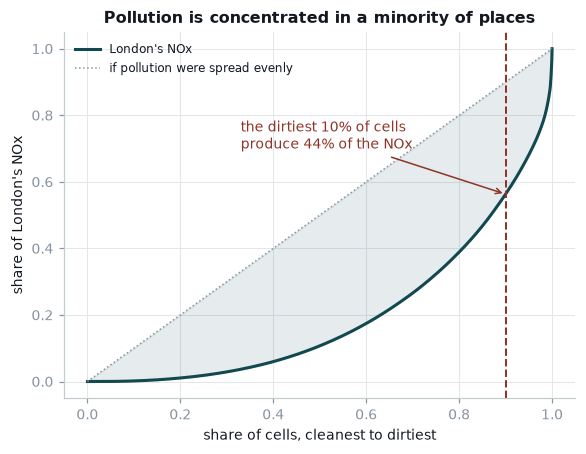

In [10]:
# cumulative share of cells (x) against cumulative share of pollution (y)
cum_cells     = np.arange(1, len(nox_sorted) + 1) / len(nox_sorted)
cum_pollution = nox_sorted.cumsum() / nox_sorted.sum()

fig, ax = plt.subplots(figsize=(5.4, 4.2))
ax.plot(cum_cells, cum_pollution, color=ACCENT, lw=2, label="London's NOx")
ax.plot([0, 1], [0, 1], color=MUTED, lw=1, ls=":",
        label="if pollution were spread evenly")
ax.fill_between(cum_cells, cum_pollution, cum_cells, color=ACCENT, alpha=.10)

top10 = 100 * nox_sorted.tail(346).sum() / nox_sorted.sum()
ax.axvline(.90, color=BRICK, lw=1.3, ls="--")
ax.annotate(f"the dirtiest 10% of cells\nproduce {top10:.0f}% of the NOx",
            xy=(.90, 1 - top10/100), xytext=(.33, .70), color=BRICK, fontsize=9,
            arrowprops=dict(arrowstyle="->", color=BRICK, lw=1))

ax.set_xlabel("share of cells, cleanest to dirtiest")
ax.set_ylabel("share of London's NOx")
ax.set_title("Pollution is concentrated in a minority of places")
ax.legend(frameon=False, fontsize=8, loc="upper left")
plt.tight_layout(); save(fig, "03_lorenz_nox"); plt.show()

> ### What this means
>
> If pollution were spread evenly, the blue line would sit on the dotted
> diagonal. It bows well below it, which means **a minority of cells carry a
> disproportionate share**.
>
> This changes what is worth building. If the problem were spread evenly, the
> Department would need an accurate estimate everywhere. Because it is
> concentrated, **finding the worst places is more valuable than estimating all
> of them precisely** — and "is this cell one of the worst?" is a
> *classification* problem, not a regression one.
>
> **This is why one of the three models is a classifier** (Task 1, and Task 2
> Insight 4). I define a "hotspot" as a cell in the worst 10%, which works out
> at a threshold of about 27.5 tonnes per year.

## Finding 3 — Different places pollute for completely different reasons

So far pollution has been treated as one quantity. But the inventory splits every
cell across **16 sectors**. Two cells emitting the same total may be nothing
alike underneath.

In [11]:
by_sector = g.groupby("Sector")[["nox", "pm2.5"]].sum().sort_values("nox", ascending=False)
by_sector["nox_share_%"] = (100 * by_sector["nox"] / by_sector["nox"].sum()).round(1)
print("London-wide NOx by sector:\n")
print(by_sector[["nox", "nox_share_%"]].round(1).to_string())

London-wide NOx by sector:

                               nox  nox_share_%
Sector                                         
Road Transport             22289.1         49.1
Heat and Power Generation  11298.0         24.9
Aviation                    4135.7          9.1
Industrial Processes        3920.7          8.6
Construction                1343.2          3.0
River                        917.4          2.0
Rail                         699.5          1.5
Waste                        513.0          1.1
Agriculture                  203.3          0.4
Machinery                     68.3          0.2
Accidental Fires              17.3          0.0
Biomass                        0.0          0.0
Commercial Cooking             0.0          0.0
Forestry                       0.0          0.0
Gas Leakage                    0.0          0.0
Resuspension                   0.0          0.0


Across London as a whole, road transport dominates. But a London-wide average
hides local variation — which is exactly the thing that matters here. Check
whether individual cells differ.

In [12]:
# for each cell, what fraction of its NOx comes from each sector?
sector_totals = g.pivot_table(index="Grid ID 2019", columns="Sector",
                              values="nox", aggfunc="sum", fill_value=0)
sector_shares = sector_totals.div(sector_totals.sum(axis=1).where(lambda s: s > 0), axis=0)

# how much does the road-transport share vary from cell to cell?
road = sector_shares["Road Transport"] * 100
print("Road transport as a % of each cell's NOx:")
print(f"  lowest 10% of cells   : below {road.quantile(.10):.0f}%")
print(f"  typical cell (median) : {road.median():.0f}%")
print(f"  highest 10% of cells  : above {road.quantile(.90):.0f}%")

print("\nCells where road transport is NOT the biggest source:")
dominant = sector_shares.idxmax(axis=1)
print(dominant.value_counts().head(6).to_string())

Road transport as a % of each cell's NOx:
  lowest 10% of cells   : below 10%
  typical cell (median) : 53%
  highest 10% of cells  : above 86%

Cells where road transport is NOT the biggest source:
Road Transport               2170
Heat and Power Generation    1043
River                          65
Aviation                       60
Agriculture                    42
Industrial Processes           35


saved -> reports/figures/04_sector_structure.png


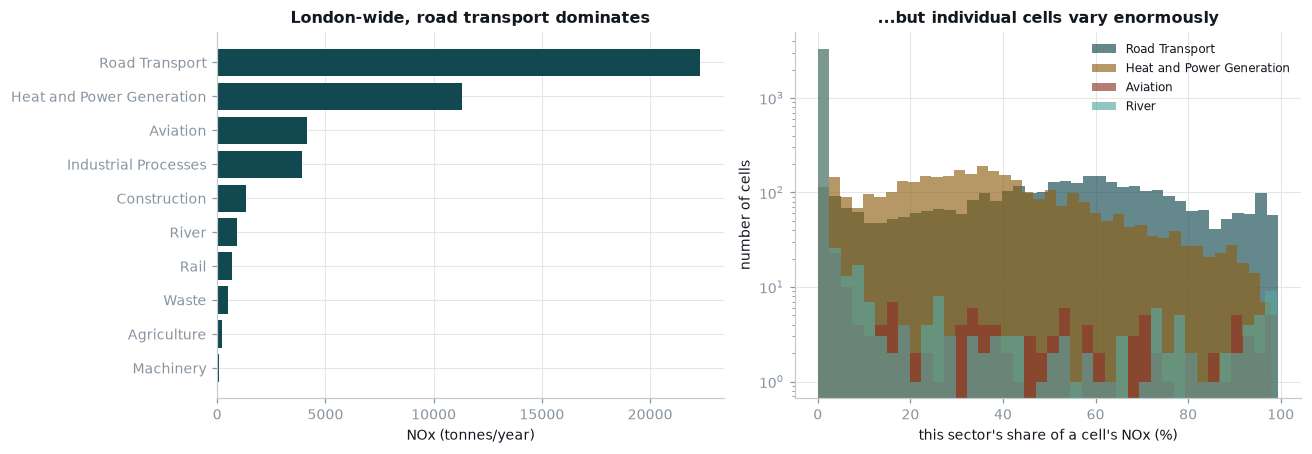

In [ ]:
"""
The code for the following plot has been obtained from Claude.
Prompt (summarised): Write matplotlib code for a two-panel figure: a
horizontal bar chart of the ten largest London-wide NOx sector totals, and
overlaid log-scale histograms of selected sectors' share of each grid
cell's NOx.
Anthropic, Claude.
https://claude.ai [accessed 5 Sep 2026].
"""

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# --- left: London-wide sector totals
s = by_sector["nox"].sort_values().tail(10)
axes[0].barh(s.index, s.values, color=ACCENT)
axes[0].set_xlabel("NOx (tonnes/year)")
axes[0].set_title("London-wide, road transport dominates")

# --- right: but the mix varies enormously between cells
for sector, colour in [("Road Transport", ACCENT), ("Heat and Power Generation", OCHRE),
                       ("Aviation", BRICK), ("River", "#5aa89f")]:
    axes[1].hist(sector_shares[sector] * 100, bins=40, alpha=.65,
                 label=sector, color=colour)
axes[1].set_xlabel("this sector's share of a cell's NOx (%)")
axes[1].set_ylabel("number of cells")
axes[1].set_yscale("log")
axes[1].set_title("...but individual cells vary enormously")
axes[1].legend(frameon=False, fontsize=8)

plt.tight_layout(); save(fig, "04_sector_structure"); plt.show()

> ### What this means
>
> The right-hand chart is the important one. Road transport's share of a cell's
> NOx ranges from near 0% to near 100%. Some cells are dominated by heating,
> a few by aviation, a few by river traffic.
>
> **This is a different kind of question, and it needs a different kind of
> model.** Predicting *how much* a cell emits will not tell the Department
> whether a road-focused policy would help there. For that they need to know
> *what kind of place it is*.
>
> Grouping things by similarity, with no target variable to predict, is
> **clustering** — an *unsupervised* method. **This is why the third algorithm is
> K-Means** (Task 1, method 3; Task 2 Insight 5).
>
> Note I cluster on the **shares** computed above, not the raw tonnes. Using
> tonnes would simply separate big cells from small ones —
> which Finding 2 already showed. Shares ask the question that actually matters:
> *what is the mix here?*

saved -> reports/figures/06_grid_map.png


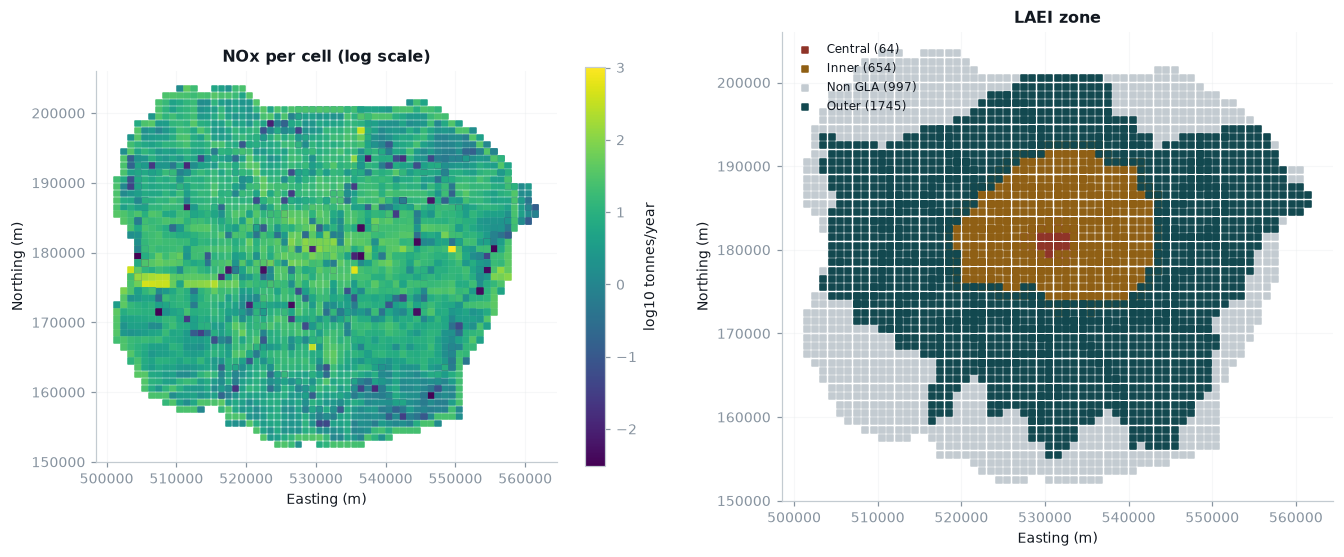

In [ ]:
"""
The code for the following plot has been obtained from Claude.
Prompt (summarised): Write matplotlib code that maps the 1 km grid cells
without a GIS library, using their Easting/Northing coordinates: one panel
coloured by log10 NOx per cell and one coloured by LAEI zone.
Anthropic, Claude.
https://claude.ai [accessed 5 Sep 2026].
"""

# Where are the cells, and how polluted are they? A map without a GIS library:
# the inventory provides Easting/Northing (British National Grid coordinates).
cells = (g.groupby("Grid ID 2019")
           .agg(Easting=("Easting", "first"), Northing=("Northing", "first"),
                Zone=("Zone", "first"))
           .join(cell_totals))

fig, axes = plt.subplots(1, 2, figsize=(12.4, 5.0))

sc = axes[0].scatter(cells["Easting"], cells["Northing"],
                     c=np.log10(cells["nox"]), s=13, cmap="viridis", marker="s")
axes[0].set_title("NOx per cell (log scale)")
plt.colorbar(sc, ax=axes[0], label="log10 tonnes/year", shrink=.85)

zone_colours = {"Central": BRICK, "Inner": OCHRE, "Outer": ACCENT, "Non GLA": "#c3cbd1"}
for zone, sub in cells.groupby("Zone"):
    axes[1].scatter(sub["Easting"], sub["Northing"], s=13, marker="s",
                    color=zone_colours.get(zone, MUTED), label=f"{zone} ({len(sub)})")
axes[1].set_title("LAEI zone")
axes[1].legend(frameon=False, fontsize=8, loc="upper left")

for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
    ax.grid(alpha=.3)
plt.tight_layout(); save(fig, "06_grid_map"); plt.show()

The bright horizontal band on the left of the first map is **Heathrow**. Keep it
in mind — in notebook 04 the clustering finds it *without ever being given a
coordinate* — which is how I validate that the clusters are real.

saved -> reports/figures/05_borough_nox.png


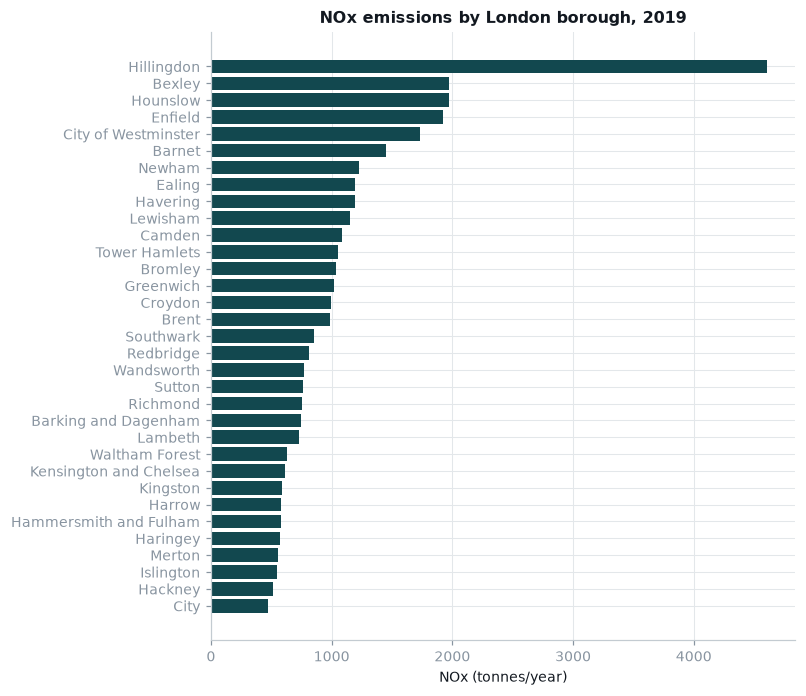

top 5 boroughs by NOx (tonnes/year):
Borough
Hillingdon             4611.0
Bexley                 1973.0
Hounslow               1973.0
Enfield                1924.0
City of Westminster    1729.0


In [15]:
# Which boroughs emit most? Useful context for the presentation.
boroughs = (g[g["Borough"] != "Non GLA"]
            .groupby("Borough")["nox"].sum()
            .sort_values())

fig, ax = plt.subplots(figsize=(7.4, 6.4))
ax.barh(boroughs.index, boroughs.values, color=ACCENT)
ax.set_xlabel("NOx (tonnes/year)")
ax.set_title("NOx emissions by London borough, 2019")
plt.tight_layout(); save(fig, "05_borough_nox"); plt.show()

print("top 5 boroughs by NOx (tonnes/year):")
print(boroughs.sort_values(ascending=False).head(5).round(0).to_string())

## Finding 4 — Emissions are a *product*, not a *sum*

This is the most important finding in the notebook, and it decides which
algorithm wins in Task 4. I now switch to the **road links** table.

In [16]:
links = laei.build_link_table()      # joins traffic data to emissions, cleans both

print(f"road links: {links.shape[0]:,} rows x {links.shape[1]} columns\n")
print("road types:")
print(links["Road Classification"].value_counts().head(6).to_string())
print(f"\nper-link NOx: median {links['nox'].median():.3f} t/yr, "
      f"max {links['nox'].max():.1f} t/yr")
print(f"link length : median {links['Link Length (m)'].median():.0f} m, "
      f"max {links['Link Length (m)'].max():,.0f} m")

road links: 79,388 rows x 57 columns

road types:
Road Classification
A Road                   39528
C / Unclassified Road    27603
B Road                   10798
M25                        939
M1                         144
M4                         138

per-link NOx: median 0.078 t/yr, max 43.8 t/yr
link length : median 43 m, max 3,770 m


Common sense says a road's emissions should depend on **how much traffic** it
carries. Check that — and also test **how long** the road is.

saved -> reports/figures/07_link_relationships.png


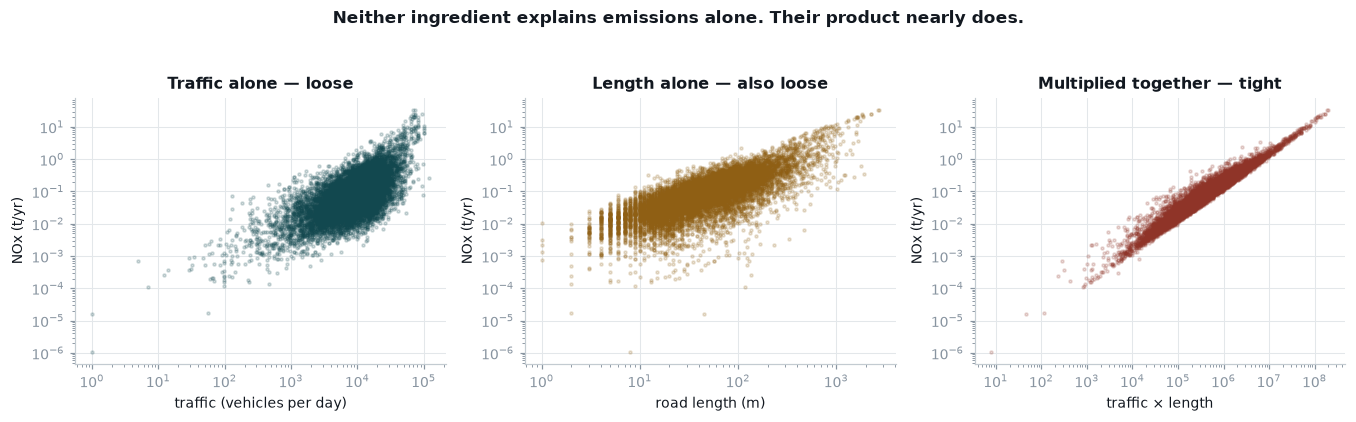

In [17]:
sample = links.sample(12000, random_state=RS)   # 12k points plot faster than 79k

fig, axes = plt.subplots(1, 3, figsize=(12.4, 3.6))

axes[0].scatter(sample["AADT 2019 - Total"], sample["nox"], s=4, alpha=.18, color=ACCENT)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("traffic (vehicles per day)"); axes[0].set_ylabel("NOx (t/yr)")
axes[0].set_title("Traffic alone — loose")

axes[1].scatter(sample["Link Length (m)"], sample["nox"], s=4, alpha=.18, color=OCHRE)
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("road length (m)"); axes[1].set_ylabel("NOx (t/yr)")
axes[1].set_title("Length alone — also loose")

product = sample["AADT 2019 - Total"] * sample["Link Length (m)"]
axes[2].scatter(product, sample["nox"], s=4, alpha=.18, color=BRICK)
axes[2].set_xscale("log"); axes[2].set_yscale("log")
axes[2].set_xlabel("traffic × length"); axes[2].set_ylabel("NOx (t/yr)")
axes[2].set_title("Multiplied together — tight")

fig.suptitle("Neither ingredient explains emissions alone. Their product nearly does.",
             y=1.05, fontsize=11, fontweight="semibold", color=INK)
plt.tight_layout(); save(fig, "07_link_relationships"); plt.show()

In [18]:
# Put numbers on what the charts show.
d = links[["AADT 2019 - Total", "Link Length (m)", "VKM 2019 - Total", "nox"]].dropna()
d = d.assign(product=d["AADT 2019 - Total"] * d["Link Length (m)"])

comparison = pd.DataFrame([
    {"predictor": "traffic only (AADT)",        "correlation with NOx": d["AADT 2019 - Total"].corr(d["nox"])},
    {"predictor": "length only",                 "correlation with NOx": d["Link Length (m)"].corr(d["nox"])},
    {"predictor": "traffic x length",            "correlation with NOx": d["product"].corr(d["nox"])},
    {"predictor": "VKM (supplied in the file)",  "correlation with NOx": d["VKM 2019 - Total"].corr(d["nox"])},
])
comparison.round(3)

,predictor,correlation with NOx
0,traffic only (AADT),0.487
1,length only,0.772
2,traffic x length,0.990
3,VKM (supplied in the file),0.990


> ### What this means — two separate lessons
>
> **Lesson 1: the relationship is multiplicative.** Traffic on its own
> correlates about **0.49** with emissions and length about **0.77**, but
> multiplied together they reach **0.99**. That makes physical sense: pollution
> accumulates along a road, so doubling *either* the traffic or the length
> roughly doubles the output.
>
> This has a sharp consequence. **A linear model can only add its inputs
> together** — it computes `a×traffic + b×length` and has no way to express
> `traffic × length` unless that column is built by hand. A **decision tree
> can**: it splits on length first, then splits on traffic *within* each length
> band, and that nesting is how a tree represents an interaction.
>
> **This is precisely why I chose both** a linear model and a tree ensemble
> (Task 1, methods 1 and 2). The comparison between them is the headline result.
>
> **Lesson 2: one column in this file is a trap.** Look at the last row of the
> table. `VKM` correlates 0.990 — *identical* to the product just built by
> hand. That is not a coincidence: **VKM = traffic × length × 365**. It is the
> GLA's own intermediate calculation, sitting in the file.
>
> A model given the VKM columns is not predicting pollution; it is redoing the
> inventory's arithmetic. This is called **data leakage**, and it will score
> beautifully while being worthless. I keep those columns separate from the
> honest ones in Part 5, and demonstrate the effect deliberately in notebook 03.

## Finding 5 — "Most polluting" depends on what you actually mean

Total emissions measure a **quantity**: how many tonnes come off this road in a
year. A long, quiet road can out-emit a short, busy one simply by being longer.

But if what you care about is what a person standing on the pavement breathes,
the relevant measure is **intensity** — emissions *per metre*. 

In [19]:
top_total     = links.nlargest(10, "nox")["Road Classification"].value_counts()
top_intensity = links.nlargest(10, "nox_per_m")["Road Classification"].value_counts()

print("The 10 worst links, by TOTAL emissions:")
print(top_total.to_string())
print("\nThe 10 worst links, by emissions PER METRE:")
print(top_intensity.to_string())

agreement = links["nox"].corr(links["nox_per_m"], method="spearman")
print(f"\nrank agreement between the two measures: {agreement:.3f}")
print("(1.0 would mean identical rankings)")

The 10 worst links, by TOTAL emissions:
Road Classification
M25    10

The 10 worst links, by emissions PER METRE:
Road Classification
A Road    10

rank agreement between the two measures: 0.642
(1.0 would mean identical rankings)


> ### What this means
>
> The two measures give **different answers**. Ranked by total emissions the
> worst links are motorway segments — they are long. Ranked per metre, busy
> urban A-roads come to the front.
>
> This is worth raising with the client rather than quietly picking one. If the
> Department's real interest is **health exposure**, then total emissions is the
> wrong target and emissions-per-metre is the right one. Choosing the wrong
> target is the kind of mistake where every model still runs, every score looks
> fine, and the answer is useless.
>
> We therefore supply **both** targets in the prepared data (Task 2, Insight 3).

saved -> reports/figures/08_link_correlations.png


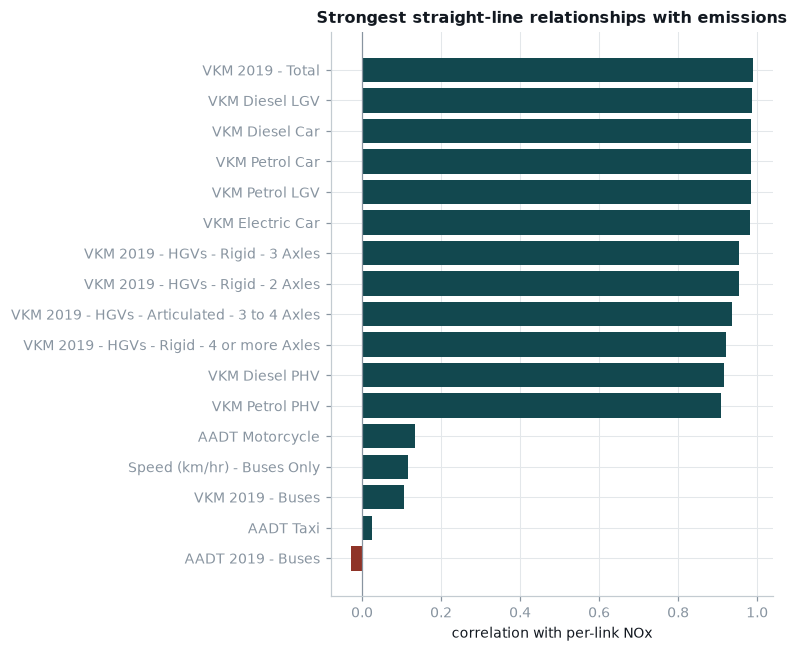

In [20]:
# Which individual measurements correlate most with emissions? Useful orientation
# before modelling, though remember correlation only detects STRAIGHT-LINE
# relationships — Finding 4 showed the real structure is multiplicative.
numeric_cols = laei.link_numeric_columns(links)
correlations = links[numeric_cols + ["nox"]].corr()["nox"].drop("nox").sort_values()
show = pd.concat([correlations.head(5), correlations.tail(12)])

fig, ax = plt.subplots(figsize=(7.2, 6.0))
ax.barh(show.index, show.values,
        color=[ACCENT if v > 0 else BRICK for v in show.values])
ax.axvline(0, color=MUTED, lw=.8)
ax.set_xlabel("correlation with per-link NOx")
ax.set_title("Strongest straight-line relationships with emissions")
plt.tight_layout(); save(fig, "08_link_correlations"); plt.show()

saved -> reports/figures/09_nox_by_road_class.png


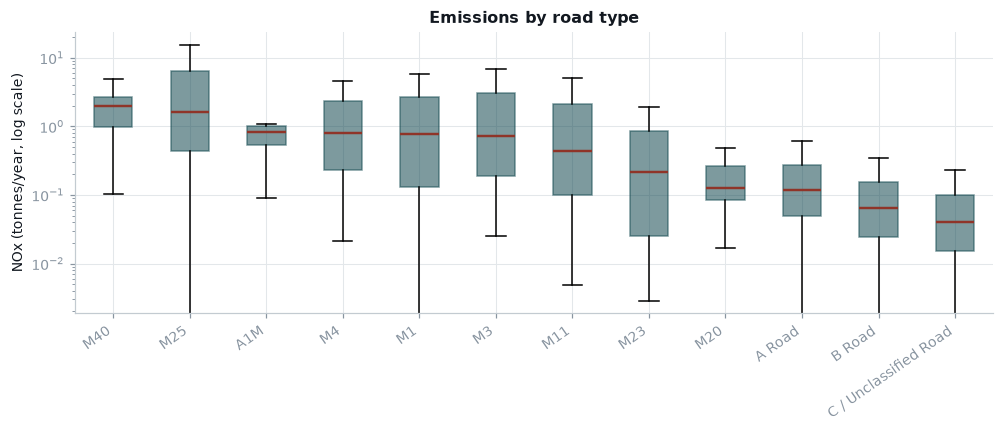

In [21]:
# Do different road types behave differently? (Used later as a model feature.)
order = (links.groupby("Road Classification")["nox"].median()
              .sort_values(ascending=False).index.tolist())
data = [links.loc[links["Road Classification"] == c, "nox"].dropna().values for c in order]

fig, ax = plt.subplots(figsize=(9.2, 4.0))
bp = ax.boxplot(data, showfliers=False, patch_artist=True)
for box in bp["boxes"]:
    box.set_facecolor(ACCENT); box.set_alpha(.55); box.set_edgecolor(ACCENT)
for median in bp["medians"]:
    median.set_color(BRICK); median.set_linewidth(1.6)
ax.set_xticks(range(1, len(order) + 1))
ax.set_xticklabels(order, rotation=35, ha="right")
ax.set_yscale("log")
ax.set_ylabel("NOx (tonnes/year, log scale)")
ax.set_title("Emissions by road type")
plt.tight_layout(); save(fig, "09_nox_by_road_class"); plt.show()

---
# Part 4 · Data quality — five traps that do not raise an error

These are the dangerous kind of problem: the code runs, no warning appears, and
the answer is wrong. Each is demonstrated below so the modeller can see the fix
is genuinely in place rather than take it on trust.

In [22]:
raw_links = laei.load_link_features()      # deliberately unprocessed, to show the problem

print("TRAP 1 — numbers arrive from Excel as text")
print("-" * 60)
example = raw_links["AADT 2019 - Total"]
print(f"  column 'AADT 2019 - Total' has dtype : {example.dtype}")
print(f"  a sample value                       : {example.dropna().iloc[0]!r}  <- a string!")
print()
print("  Why it matters: pandas will not do arithmetic on these, and a")
print("  one-hot encoder would try to make ~40,000 categories out of them.")
print("  Fixed in laei.build_link_table() with pd.to_numeric().")

TRAP 1 — numbers arrive from Excel as text
------------------------------------------------------------
  column 'AADT 2019 - Total' has dtype : str
  a sample value                       : '11338'  <- a string!

  Why it matters: pandas will not do arithmetic on these, and a
  one-hot encoder would try to make ~40,000 categories out of them.
  Fixed in laei.build_link_table() with pd.to_numeric().


### Trap 2 — the placeholder `-` means **zero**, not "missing"

Most numeric columns use `-` where a value is absent. The instinctive response
is to treat it as missing and fill it with the column median.

**That would be wrong**, and expensively so. Here is the test that settles it:
if `-` really means zero, then adding up the individual vehicle classes should
reproduce the stated total.

In [23]:
vehicle_cols = [c for c in raw_links.columns
                if c.startswith("AADT") and c != "AADT 2019 - Total"]
vehicles = raw_links[vehicle_cols].apply(pd.to_numeric, errors="coerce")
total    = pd.to_numeric(raw_links["AADT 2019 - Total"], errors="coerce")

has_dash = vehicles.isna().any(axis=1) & total.notna()   # rows with at least one '-'
no_dash  = vehicles.notna().all(axis=1) & total.notna()  # rows with none (the control)

# treat '-' as zero, then compare the sum of classes against the stated total
gap_dashed = (vehicles.fillna(0).sum(axis=1)[has_dash] - total[has_dash]).abs()
gap_clean  = (vehicles.sum(axis=1)[no_dash] - total[no_dash]).abs()

print("If '-' means ZERO, do the vehicle classes add up to the stated total?")
print("-" * 68)
print(f"  rows containing at least one '-' : {has_dash.sum():>7,}")
print(f"     ...where the sum matches exactly : {(gap_dashed < 1e-6).sum():>7,}")
print(f"     ...largest disagreement          : {gap_dashed.max():>7.1f} vehicles")
print()
print(f"  CONTROL: rows with no '-' at all  : {no_dash.sum():>7,}")
print(f"     ...largest disagreement          : {gap_clean.max():>7.1f} vehicles")
print()
print("  Identical tolerance -> '-' means ZERO VEHICLES. I fill it with 0.")
print(f"  Had I median-imputed instead, I would have invented traffic on")
print(f"  {100*has_dash.sum()/len(raw_links):.0f}% of the road network.")

If '-' means ZERO, do the vehicle classes add up to the stated total?
--------------------------------------------------------------------
  rows containing at least one '-' :  33,705
     ...where the sum matches exactly :  17,117
     ...largest disagreement          :     3.0 vehicles

  CONTROL: rows with no '-' at all  :  45,043
     ...largest disagreement          :     3.0 vehicles

  Identical tolerance -> '-' means ZERO VEHICLES. I fill it with 0.
  Had I median-imputed instead, I would have invented traffic on
  42% of the road network.


In [24]:
print("TRAP 3 — the Speed columns are the exception")
print("-" * 60)
speed_dashes = (raw_links["Speed (km/hr) - Buses Only"].astype(str).str.strip() == "-").sum()
buses = (pd.to_numeric(raw_links["AADT 2019 - Buses"], errors="coerce").fillna(0)
         + pd.to_numeric(raw_links["AADT 2019 - Coaches"], errors="coerce").fillna(0))
dashed = raw_links["Speed (km/hr) - Buses Only"].astype(str).str.strip() == "-"

print(f"  links with no buses-only speed recorded : {speed_dashes:,}")
print(f"  ...of which genuinely have no buses     : {(dashed & (buses == 0)).sum():,}")
print(f"  ...but DO carry buses                   : {(dashed & (buses > 0)).sum():,}")
print()
print("  So here '-' really does mean MISSING, not zero — a speed of 0 km/h")
print("  would be a false reading. These are left blank for the model to")
print("  impute, with a 'bus_speed_missing' flag so it knows.")
print()
print("  Lesson: the same placeholder can mean different things in different")
print("  columns. Check, do not assume.")

TRAP 3 — the Speed columns are the exception
------------------------------------------------------------


  links with no buses-only speed recorded : 26,998
  ...of which genuinely have no buses     : 11,109
  ...but DO carry buses                   : 15,889

  So here '-' really does mean MISSING, not zero — a speed of 0 km/h
  would be a false reading. These are left blank for the model to
  impute, with a 'bus_speed_missing' flag so it knows.

  Lesson: the same placeholder can mean different things in different
  columns. Check, do not assume.


In [25]:
print("TRAP 4 — the same place is spelled differently in different files")
print("-" * 60)
print(f"  grid file uses      : {sorted(g['Zone'].unique())}")
print(f"  road file uses      : {sorted(raw_links['LAEI Zone'].unique())}")
print()
print("  Joining these without tidying would split 'Non GLA' into two groups")
print("  that never match. laei.ZONE_CANON normalises them.")
print(f"  after normalising   : {sorted(links['zone_canon'].unique())}")

print("\n\nTRAP 5 — PM is recorded three times per road")
print("-" * 60)
targets = laei.load_link_targets()
print(f"  unique roads in the targets file : {len(targets):,}")
print(f"  total PM10 (t/yr)                : {targets['pm10'].sum():,.1f}")
print(f"  total PM2.5 (t/yr)               : {targets['pm25'].sum():,.1f}")
print(f"  PM10 / PM2.5 ratio               : {targets['pm10'].sum()/targets['pm25'].sum():.2f}")
print()
print("  Particulates come from exhaust, brake wear AND tyre wear, stored as")
print("  three separate rows per road. They must be ADDED together. Keying a")
print("  dictionary on road ID would silently keep only the last one and lose")
print("  about two thirds of the PM. (I made this mistake, and caught it.)")

TRAP 4 — the same place is spelled differently in different files
------------------------------------------------------------
  grid file uses      : ['Central', 'Inner', 'Non GLA', 'Outer']
  road file uses      : ['Central London', 'Inner London', 'Non-GLA', 'Outer London']

  Joining these without tidying would split 'Non GLA' into two groups
  that never match. laei.ZONE_CANON normalises them.
  after normalising   : ['Central', 'Inner', 'Non GLA', 'Outer']


TRAP 5 — PM is recorded three times per road
------------------------------------------------------------
  unique roads in the targets file : 79,439
  total PM10 (t/yr)                : 2,239.7
  total PM2.5 (t/yr)               : 1,157.0
  PM10 / PM2.5 ratio               : 1.94

  Particulates come from exhaust, brake wear AND tyre wear, stored as
  three separate rows per road. They must be ADDED together. Keying a
  dictionary on road ID would silently keep only the last one and lose
  about two thirds of the PM. (I made

---
# Part 5 · Preparing the data for the three algorithms

Everything above was diagnosis. Now I build the three tables the modeller will
actually use — one per algorithm, each shaped for the question it answers.

| Table | One row is | For | Answers |
|---|---|---|---|
| **A** | a road link | Linear Regression, Random Forest | *What does this road emit?* |
| **B** | a 1 km cell | K-Means | *What kind of place is this?* |
| **C** | a 1 km cell | Random Forest classifier | *Is this a hotspot?* |

### Table A — road links

**Target:** `nox`, in tonnes per year. I also supply `pm10`, `pm25`, `co2` and
`nox_per_m` as alternatives.

The important part is that I define **two feature sets**, and the difference
between them is the experiment:

- **`realistic`** — traffic counts, speeds and geometry. This is what a borough
  monitoring unit actually holds, and it is the honest test.
- **`full`** — the same plus the VKM columns. Finding 4 showed these are the
  inventory's own workings. I keep them **only** to demonstrate leakage.

In [26]:
feature_sets = laei.link_feature_sets(links)

for name, cols in feature_sets.items():
    print(f"  {name:<10} {len(cols)} numeric features")
print(f"  {'categorical':<10} {laei.LINK_CATEGORICAL}")

table_a_cols = (["TOID"] + laei.LINK_CATEGORICAL
                + ["zone_canon", "is_motorway", "no_traffic_data", "bus_speed_missing"]
                + feature_sets["full"] + ["nox", "pm10", "pm25", "co2", "nox_per_m"])

table_a = links[table_a_cols].copy()
table_a.to_csv(PROC / "table_A_links.csv", index=False)
print(f"\nwrote table_A_links.csv : {table_a.shape[0]:,} rows x {table_a.shape[1]} columns")

  full       43 numeric features
  realistic  23 numeric features
  categorical ['LAEI Zone', 'Borough', 'Road Classification']



wrote table_A_links.csv : 79,388 rows x 56 columns


### Table B — grid cells, for clustering

**No target** — clustering is unsupervised.

Two deliberate choices, both explained in Finding 3:

1. **I use shares, not tonnes**, so the algorithm finds *kinds of place* rather
   than just big and small ones.
2. **I exclude the coordinates from the features.** They go in the file for
   drawing maps, but the clustering never sees them. If London's geography
   emerges anyway, that is strong evidence the grouping is real — and it is a
   validation I could not run if I had fed the coordinates in.

I also standardise the features, because K-Means measures distances and would
otherwise be dominated by whichever column happens to have the largest numbers.

In [27]:
from sklearn.preprocessing import StandardScaler

table_b, sectors = laei.build_grid_source_mix("nox", 2019)
shares = laei.to_shares(table_b, sectors)
shares.columns = [f"share_{c}" for c in shares.columns]

table_b_out = pd.concat([table_b[laei.GRID_KEYS], shares, table_b[laei.MODELLABLE]], axis=1)
table_b_out.to_csv(PROC / "table_B_grid_source_mix.csv", index=False)

# standardised and ready to fit — the modeller can load this and go
X_kmeans = StandardScaler().fit_transform(shares.values)
np.save(PROC / "table_B_kmeans_matrix.npy", X_kmeans)

print(f"wrote table_B_grid_source_mix.csv : {table_b_out.shape[0]:,} rows x {table_b_out.shape[1]} cols")
print(f"wrote table_B_kmeans_matrix.npy   : {X_kmeans.shape}  (standardised, fit-ready)")
print(f"\nthe {len(sectors)} clustering features are the sector shares:")
print("  " + ", ".join(sectors))

wrote table_B_grid_source_mix.csv : 3,460 rows x 25 cols
wrote table_B_kmeans_matrix.npy   : (3460, 16)  (standardised, fit-ready)

the 16 clustering features are the sector shares:
  Accidental Fires, Agriculture, Aviation, Biomass, Commercial Cooking, Construction, Forestry, Gas Leakage, Heat and Power Generation, Industrial Processes, Machinery, Rail, Resuspension, River, Road Transport, Waste


### Table C — grid cells, for classification

**Targets:** `nox` (a number) and `nox_hotspot` (yes/no — is this cell in the
worst 10%?).

**Features: CO2 by sector, plus location.** This choice needs explaining,
because the obvious alternative is a trap.

The obvious thing would be to predict a cell's total NOx from its NOx by sector.
But those 16 columns *add up to* the target — the model would just be doing
addition, scoring near-perfectly and learning nothing. That is the same leakage
problem as VKM in Finding 4.

Using **CO2** instead asks a genuinely different question. CO2 tells you *how
much fuel is burned*; NOx additionally depends on *how cleanly* it burns. So the
model is really asking: **given how much energy is used here, and where here is,
how dirty is the burning?**

And this is the clever part: **I expect this model to be imperfect, and the
imperfection is the useful output.** Cells where actual NOx is much higher than
the CO2 prediction are burning dirtier than their energy use implies — which is
exactly the list of places worth investigating.

In [28]:
table_c, features_c = laei.build_grid_nonleaky(2019, hotspot_quantile=0.90)
threshold = table_c.attrs["hotspot_threshold"]

table_c.to_csv(PROC / "table_C_grid_nonleaky.csv", index=False)

print(f"wrote table_C_grid_nonleaky.csv : {table_c.shape[0]:,} rows x {table_c.shape[1]} cols")
print(f"features: {len(features_c)} ({len(features_c)-2} CO2-by-sector + Easting + Northing)")
print()
print(f"a cell counts as a 'hotspot' above  : {threshold:,.2f} tonnes/year")
print(f"hotspots found                      : {table_c['nox_hotspot'].sum():,} of {len(table_c):,}"
      f"  ({100*table_c['nox_hotspot'].mean():.0f}%)")
print()
print("Note the 1:9 imbalance. Two consequences for the modeller:")
print("  - use stratify=y when splitting, so both halves keep the same 10%")
print("  - do NOT report accuracy: always guessing 'not a hotspot' scores 90%")

wrote table_C_grid_nonleaky.csv : 3,460 rows x 25 cols
features: 18 (16 CO2-by-sector + Easting + Northing)

a cell counts as a 'hotspot' above  : 27.52 tonnes/year
hotspots found                      : 346 of 3,460  (10%)

Note the 1:9 imbalance. Two consequences for the modeller:
  - use stratify=y when splitting, so both halves keep the same 10%
  - do NOT report accuracy: always guessing 'not a hotspot' scores 90%


In [29]:
# Also save the LEAKY version, purely so the modeller can demonstrate the effect.
leaky = pd.concat([table_b[["Grid ID 2019"]], table_b[sectors], table_b[["nox"]]], axis=1)
leaky["nox_hotspot"] = table_c.set_index("Grid ID 2019").loc[
    leaky["Grid ID 2019"], "nox_hotspot"].values
leaky.to_csv(PROC / "table_C_LEAKY_reference.csv", index=False)

print("wrote table_C_LEAKY_reference.csv")
print()
print("  WARNING: this file exists ONLY as a demonstration. Its 16 features add")
print("  up to its target, so any model scores ~0.99 while learning nothing.")
print("  Showing that you can DETECT leakage is a stronger result than quietly")
print("  avoiding it — but never report this as a model's performance.")

wrote table_C_LEAKY_reference.csv

  up to its target, so any model scores ~0.99 while learning nothing.
  Showing that you can DETECT leakage is a stronger result than quietly
  avoiding it — but never report this as a model's performance.


### The preprocessing recipe

One shared recipe, used by every model, and always placed **inside** a
scikit-learn `Pipeline`.

Why inside? Because scaling uses statistics like the mean and standard
deviation. If those are calculated from the whole dataset, information from the
test set leaks into training and the score comes out flattering. A Pipeline
recalculates them separately for each training fold, which is correct.

In [30]:
from sklearn.model_selection import train_test_split

numeric = feature_sets["realistic"]
pre = laei.make_preprocessor(numeric, laei.LINK_CATEGORICAL)

X = links[numeric + laei.LINK_CATEGORICAL]
y = links["nox"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RS)

X_encoded = pre.fit_transform(X_train)

print(f"training rows / test rows : {len(X_train):,} / {len(X_test):,}")
print(f"columns after encoding    : {X_encoded.shape[1]}")
print(f"   {len(numeric)} numeric (blanks filled with the median, then standardised)")
print(f"   {X_encoded.shape[1] - len(numeric)} extra columns from one-hot encoding "
      f"{laei.LINK_CATEGORICAL}")
print()
print("One-hot encoding turns a text column like Borough into one 0/1 column per")
print("borough, because models need numbers rather than words.")

training rows / test rows : 63,510 / 15,878
columns after encoding    : 73
   23 numeric (blanks filled with the median, then standardised)
   50 extra columns from one-hot encoding ['LAEI Zone', 'Borough', 'Road Classification']

One-hot encoding turns a text column like Borough into one 0/1 column per
borough, because models need numbers rather than words.


### The manifest

Finally a small JSON file describing everything above. The modelling
notebooks read it rather than hardcoding column names, so if this preparation is
ever re-run, their code follows automatically.

In [31]:
manifest = {
    "project": "LAEI 2019 — atmospheric emissions ML",
    "source": {
        "dataset": "London Atmospheric Emissions Inventory (LAEI) 2019",
        "publisher": "Greater London Authority, Environment Team",
        "datastore_id": "e758q",
        "licence": "UK Open Government Licence v3.0",
        "note": "Superseded by LAEI 2022 in August 2025; 2019 used as the brief specifies.",
    },
    "base_year": 2019,
    "excluded_years": list(laei.FORECAST_YEARS),
    "environment": {
        "python": sys.version.split()[0],
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scikit_learn": sklearn.__version__,
    },
    "tables": {
        "table_A_links.csv": {
            "algorithms": ["LinearRegression", "RandomForestRegressor"],
            "unit": "one major road link (OS TOID)",
            "rows": int(table_a.shape[0]),
            "targets": {"primary": "nox",
                        "alternatives": ["pm10", "pm25", "co2", "nox_per_m"],
                        "units": "tonnes/year"},
            "feature_sets": {k: len(v) for k, v in feature_sets.items()},
            "categorical": laei.LINK_CATEGORICAL,
            "quality_flags": {
                "no_traffic_data": int(links["no_traffic_data"].sum()),
                "bus_speed_missing": int(links["bus_speed_missing"].sum()),
            },
            "placeholder_handling": "'-' in AADT/VKM means ZERO VEHICLES (verified: "
                                    "sum of classes == stated total) and is zero-filled. "
                                    "'-' in the Speed columns means MISSING and is left NaN "
                                    "for median imputation, with bus_speed_missing as an indicator.",
            "warning": "The 'full' set contains VKM, which LAEI uses to COMPUTE the "
                       "target. Use it only as a leakage demonstration.",
        },
        "table_B_grid_source_mix.csv": {
            "algorithms": ["KMeans"],
            "unit": "one 1 km grid cell",
            "rows": int(table_b_out.shape[0]),
            "features": [f"share_{s}" for s in sectors],
            "matrix": "table_B_kmeans_matrix.npy (standardised, fit-ready)",
            "note": "Easting/Northing are for validation and plotting only — "
                    "do NOT include them as clustering features.",
        },
        "table_C_grid_nonleaky.csv": {
            "algorithms": ["RandomForestClassifier", "LinearRegression"],
            "unit": "one 1 km grid cell",
            "rows": int(table_c.shape[0]),
            "features": features_c,
            "targets": {"regression": "nox", "classification": "nox_hotspot"},
            "hotspot_threshold_tonnes_yr": round(float(threshold), 4),
            "positive_rate": round(float(table_c["nox_hotspot"].mean()), 4),
        },
        "table_C_LEAKY_reference.csv": {
            "purpose": "Leakage demonstration only — features sum to the target.",
        },
    },
    "modelling_protocol": {
        "split": "train_test_split(test_size=0.2, random_state=42); stratify=y for classification",
        "cross_validation": "KFold(5, shuffle=True, random_state=42); "
                            "GroupKFold(groups=Borough) as a spatial sanity check",
        "preprocessing": "laei.make_preprocessor(numeric, categorical) inside a Pipeline",
        "regression_metrics": ["R2", "MAE", "RMSE"],
        "classification_metrics": ["ROC-AUC", "precision", "recall", "F1"],
        "baselines": ["DummyRegressor(strategy='median')", "DummyClassifier(strategy='stratified')"],
        "note": "Report MAE alongside RMSE. Targets are strongly right-skewed, so the two "
                "metrics can rank models differently — that difference is a finding.",
    },
}

with open(PROC / "manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("wrote manifest.json\n")
print(json.dumps(manifest["modelling_protocol"], indent=2))

wrote manifest.json

{
  "split": "train_test_split(test_size=0.2, random_state=42); stratify=y for classification",
  "cross_validation": "KFold(5, shuffle=True, random_state=42); GroupKFold(groups=Borough) as a spatial sanity check",
  "preprocessing": "laei.make_preprocessor(numeric, categorical) inside a Pipeline",
  "regression_metrics": [
    "R2",
    "MAE",
    "RMSE"
  ],
  "classification_metrics": [
    "ROC-AUC",
    "precision",
    "recall",
    "F1"
  ],
  "baselines": [
    "DummyRegressor(strategy='median')",
    "DummyClassifier(strategy='stratified')"
  ],
  "note": "Report MAE alongside RMSE. Targets are strongly right-skewed, so the two metrics can rank models differently \u2014 that difference is a finding."
}


---
# Part 6 · Summary — from findings to decisions

### What I found, and what I did about it

| Finding | What it showed | What I decided |
|---|---|---|
| **1** · Emissions are extremely unevenly spread | A few places are hundreds of times worse than typical | Prefer models robust to extremes; never impute with the mean; always report MAE **and** RMSE |
| **2** · A minority of cells carry most of the pollution | Finding the worst places beats estimating everywhere | Build a **classifier** to identify hotspots |
| **3** · Different places pollute for different reasons | A total hides whether a policy would even apply | Build a **clustering** model on source *shares* |
| **4** · Emissions are traffic **×** length | Linear models cannot express a product; trees can | Build **both**, and compare — this is the headline result |
| **5** · Quantity and intensity rank roads differently | The client may want the other target | Supply both `nox` and `nox_per_m` |

### The three algorithms this justifies

1. **Linear Regression** — because the inventory is *built* as a weighted sum,
   and because it is the only model that gives a usable number per vehicle type.
2. **Random Forest** — because Finding 4 showed the real relationship is a
   product, and because Finding 1 showed the need for robustness to extremes.
3. **K-Means** — because Finding 3 showed that *what kind of place this is*
   matters as much as how much it emits.

Full reasoning in `reports/Task1_Task2_Report.md`.

### What is handed over for modeling

| File | For |
|---|---|
| `table_A_links.csv` | Linear Regression, Random Forest (regression) |
| `table_B_grid_source_mix.csv` + `table_B_kmeans_matrix.npy` | K-Means |
| `table_C_grid_nonleaky.csv` | Classification |
| `table_C_LEAKY_reference.csv` | Leakage demonstration **only** |
| `manifest.json` | Machine-readable description of all of the above |

### Three things the modeller must not undo

1. **Do not add VKM to the realistic feature set** — it is the inventory's own
   input to the answer (Finding 4).
2. **Do not add coordinates to the clustering features** — geography emerging
   without them is the validation (Finding 3).
3. **Do not report the leaky table as a result** — its features sum to its
   target.

### Honest limits of this data

Worth stating plainly, because a consultancy that omits them is not doing its
job:

- LAEI is **modelled, not measured**. A high score means I reproduced the GLA's
  model, not that I predicted the air.
- **Annual totals only** — no daily or seasonal pattern, so this cannot forecast
  tomorrow's air quality.
- **Emissions, not concentrations.** I deliberately left out weather and
  dispersion, which are what turn emissions into what people actually breathe.
- **One year**, from a vintage since superseded. Any multi-year model must
  account for the GLA changing its own method between releases, or it will read
  those changes as real trends.


### References

Lorenz, M.O. (1905) 'Methods of measuring the concentration of wealth',
*Publications of the American Statistical Association*, 9(70), pp. 209–219.
doi: 10.2307/2276207.